In [4]:
def yolo_to_bbox(yolo_coords, img_width, img_height):
    """
    Конвертирует YOLO формат в абсолютные координаты bounding box.
    
    Параметры:
    yolo_coords: tuple или list (x_center, y_center, width_norm, height_norm)
    img_width: ширина изображения в пикселях
    img_height: высота изображения в пикселях
    
    Возвращает:
    dict: {'xmin': int, 'ymin': int, 'xmax': int, 'ymax': int}
    """
    if hasattr(yolo_coords, 'values'):
        x_center, y_center, w_norm, h_norm = yolo_coords.values
    else:
        x_center, y_center, w_norm, h_norm = yolo_coords
    
    # Конвертируем в числа (на всякий случай)
    x_center = float(x_center)
    y_center = float(y_center)
    w_norm = float(w_norm)
    h_norm = float(h_norm)
    img_width = float(img_width)
    img_height = float(img_height)
    
    # Конвертируем нормализованные координаты в абсолютные
    x_center_abs = x_center * img_width
    y_center_abs = y_center * img_height
    w_abs = w_norm * img_width
    h_abs = h_norm * img_height
    
    # Вычисляем xmin, ymin, xmax, ymax
    xmin = int(x_center_abs - w_abs / 2)
    ymin = int(y_center_abs - h_abs / 2)
    xmax = int(x_center_abs + w_abs / 2)
    ymax = int(y_center_abs + h_abs / 2)
    
    # Обрезаем до границ изображения
    xmin = max(0, xmin)
    ymin = max(0, ymin)
    xmax = min(img_width, xmax)
    ymax = min(img_height, ymax)
    
    return xmin, ymin, xmax, ymax

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import cv2 as cv
import yaml
import xml.etree.ElementTree as ET

df_patches = pd.read_csv('data/Annotations/patches.csv')
df_patches = df_patches.drop('Unnamed: 0', axis = 1)

In [2]:
df_patches

,filename,images_id,patch_id,x_center,y_center,width,height,class_id
0,levle0_1-0.jpg,1,0,0.578406,0.913628,0.035347,0.031829,0
1,levle0_1-0.jpg,1,0,0.352667,0.988860,0.024100,0.021701,0
2,levle0_1-0.jpg,1,0,0.913400,0.579427,0.024100,0.021701,0
3,levle0_1-0.jpg,1,0,0.356282,0.722295,0.079531,0.094763,0
4,levle0_1-1.jpg,1,1,0.078406,0.913628,0.035347,0.031829,0
...,...,...,...,...,...,...,...,...
99407,levle3_97-26.jpg,1456,26,0.283082,0.647672,0.072272,0.234069,0
99408,levle3_97-26.jpg,1456,26,0.384619,0.734681,0.089068,0.162990,0
99409,levle3_97-26.jpg,1456,26,0.094768,0.107843,0.101792,0.193627,0
99410,levle3_97-27.jpg,1456,27,0.035525,0.490196,0.022394,0.053922,0


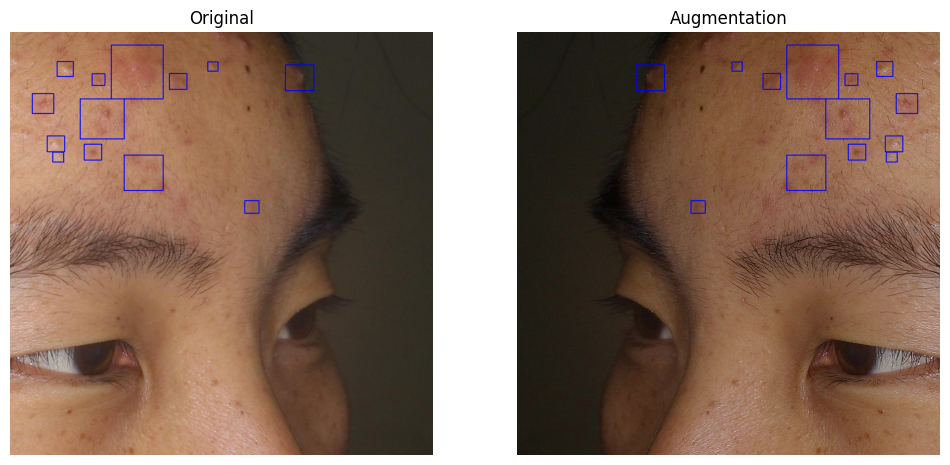

In [12]:
import albumentations as A
import torch

from src.utils.transforms import return_transforms
image_name = 'levle2_101-6.jpg'
path = f'data/Patches/{image_name}'

img = Image.open(path).convert('RGB')
img_arr = np.array(img)
img_show = np.array(img)
H, W, C = img_arr.shape

frame = df_patches[df_patches['filename'] == image_name]
transform = return_transforms()

boxes = []
labels = []
if len(frame) > 0:
    for _, row in frame.iterrows():
        x_center, y_center, width, height = row['x_center'], row['y_center'], row['width'], row['height']
        boxes.append([x_center, y_center, width, height])
        labels.append(row['class_id'])
        xmin, ymin, xmax, ymax = yolo_to_bbox((x_center, y_center, width, height), img_height=H, img_width=W)
        cv.rectangle(img_show, (int(xmin), int(ymax)), (int(xmax), int(ymin)), (0, 0, 255), 2)

#boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
#labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.tensor([], dtype=torch.int64)
#print(boxes)
#print(labels)


transformed = transform(image = img_arr, bboxes = boxes, labels = labels)

fig, (ax1, ax2) = plt.subplots(nrows = 1,ncols = 2, figsize = (12, 24))
#fig.figure(fig_size = (8, 16))
ax1.imshow(img_show)
ax1.axis('off')
ax1.set_title('Original')

img_transformed = np.copy(transformed['image'])

for item in transformed['bboxes']:
    x_center, y_center, width, height = item
    xmin, ymin, xmax, ymax = yolo_to_bbox((x_center, y_center, width, height), img_height=H, img_width=W)
    cv.rectangle(img_transformed, (int(xmin), int(ymax)), (int(xmax), int(ymin)), (0, 0, 255), 2)

ax2.imshow(img_transformed)
ax2.axis('off')
ax2.set_title('Augmentation')

plt.show()

